# Breast cancer classification

Wisconsin dataset, 569 samples, 30 features. Small neural net with logistic
regression as a baseline. Malignant is the positive class, so recall on
malignant is what matters.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series((data.target == 0).astype(int))  # 1 = malignant
y.value_counts().to_dict()

{0: 357, 1: 212}

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [4]:
# baseline
base = LogisticRegression(max_iter=5000).fit(X_train_s, y_train)
print(f"logreg: acc {accuracy_score(y_test, base.predict(X_test_s)):.3f}, "
      f"recall {recall_score(y_test, base.predict(X_test_s)):.3f}, "
      f"auc {roc_auc_score(y_test, base.predict_proba(X_test_s)[:, 1]):.3f}")

logreg: acc 0.965, recall 0.929, auc 0.996


In [5]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_s.shape[1],)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early = keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor="val_loss")
history = model.fit(X_train_s, y_train.to_numpy(), validation_split=0.2,
                    epochs=200, batch_size=16, callbacks=[early], verbose=0)
print(f"stopped after {len(history.history['loss'])} epochs")

stopped after 49 epochs


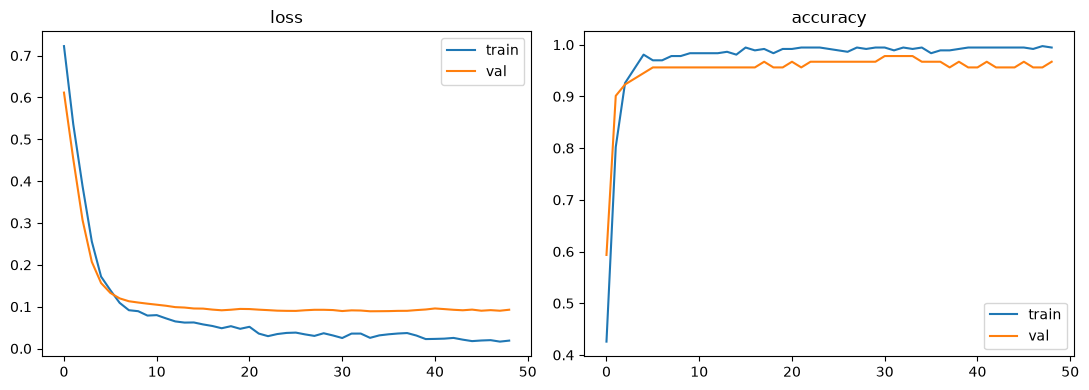

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history.history["loss"], label="train")
ax[0].plot(history.history["val_loss"], label="val")
ax[0].set_title("loss"); ax[0].legend()
ax[1].plot(history.history["accuracy"], label="train")
ax[1].plot(history.history["val_accuracy"], label="val")
ax[1].set_title("accuracy"); ax[1].legend()
plt.tight_layout(); plt.show()

accuracy  0.982
precision 1.000
recall    0.952
f1        0.976
roc-auc   0.995


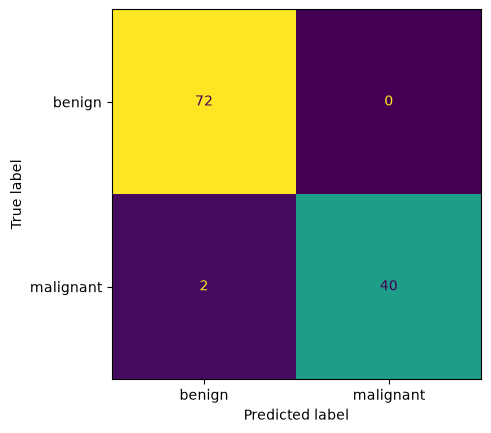

In [7]:
proba = model.predict(X_test_s, verbose=0).ravel()
pred = (proba >= 0.5).astype(int)
print(f"accuracy  {accuracy_score(y_test, pred):.3f}")
print(f"precision {precision_score(y_test, pred):.3f}")
print(f"recall    {recall_score(y_test, pred):.3f}")
print(f"f1        {f1_score(y_test, pred):.3f}")
print(f"roc-auc   {roc_auc_score(y_test, proba):.3f}")

ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["benign", "malignant"]).plot(colorbar=False)
plt.show()

Net and baseline are basically tied. On ~570 clean rows a linear model is already
strong, so the network doesn't add much here.